# Flux Step Response Analysis (arXiv:2503.04610, Figure 4)

Load flux_lead_time sweep data, fit the step response in normalized flux space,
extract α₀, αᵢ, τᵢ parameters, and validate the IIR compensation filter.

In [24]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

In [25]:
from slab_qick_calib.experiments.flux.pulse_probe_spectroscopy_flux import QubitSpecFluxSweep

data_path = r"C:\_Data\sample_50_new\data\qspec_sweep_flux_lead_time_qubit2_00010.h5"
expt = QubitSpecFluxSweep.from_h5file(data_path)

print(f"Sweep points: {len(expt.data['sweep_pts'])}")
print(f"Time range: {expt.data['sweep_pts'].min():.3f} - {expt.data['sweep_pts'].max():.1f} µs")
print(f"Freq range: {expt.data['qubit_freq_list'].min():.1f} - {expt.data['qubit_freq_list'].max():.1f} MHz")

Sweep points: 70
Time range: 0.010 - 100.0 µs
Freq range: 2778.6 - 2920.6 MHz


## Flux-space fit with α₀ free

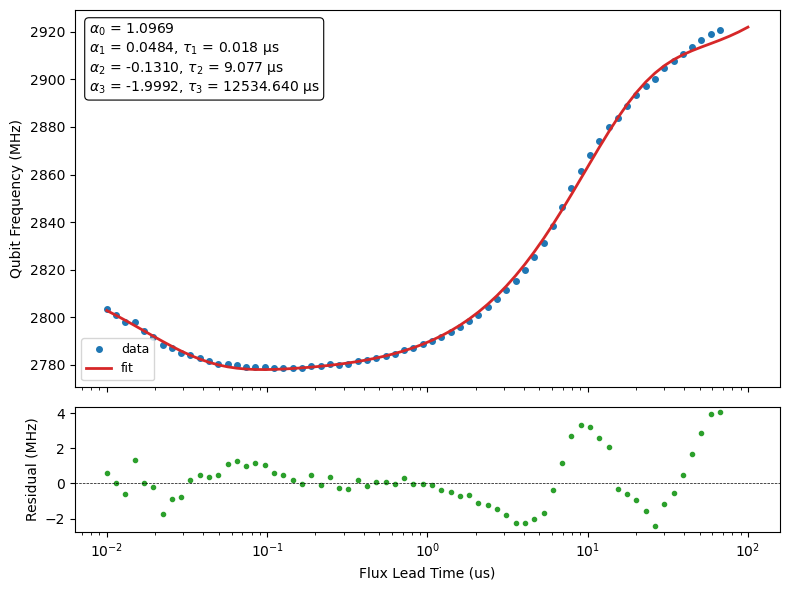

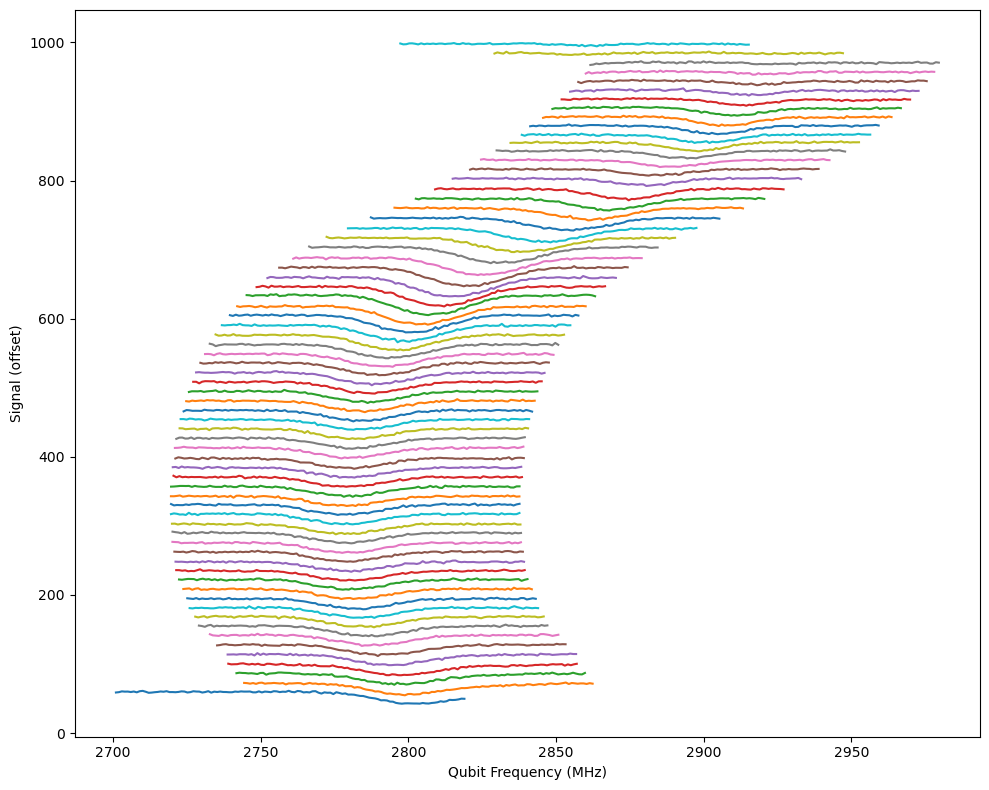

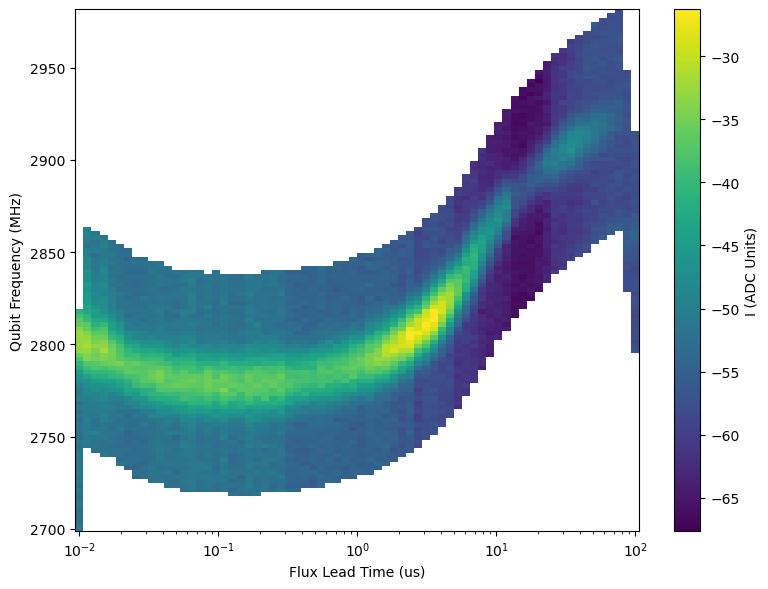

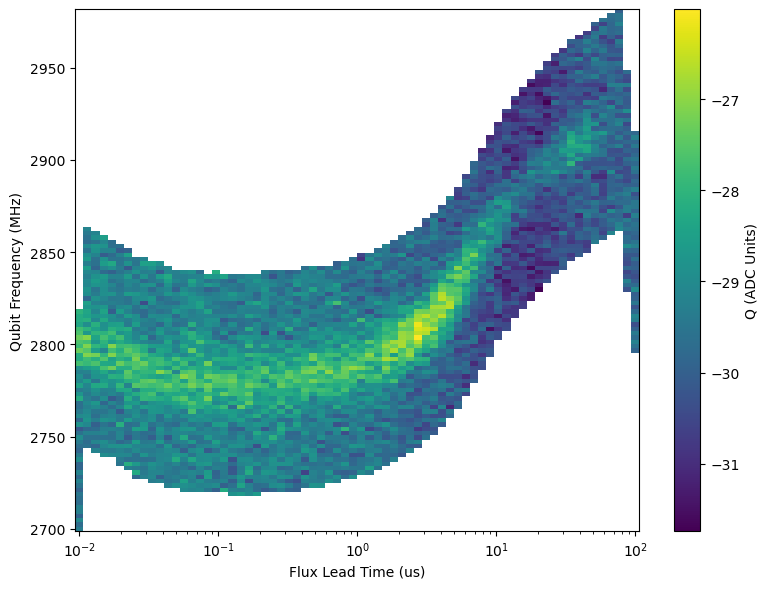


α₀ = 1.0969
α1 = 0.0484, τ1 = 0.018 µs
α2 = -0.1310, τ2 = 9.077 µs
α3 = -1.9992, τ3 = 12534.640 µs

Σαᵢ = -2.0818
α₀ + Σαᵢ = -0.9848  (should be ≈ s(0) ≈ 1)

Outliers hidden: 3 points (>2σ)


In [26]:
from slab_qick_calib.analysis.fitting import TransmonFluxConverter

converter = TransmonFluxConverter(
    f_max=3471.3869, E_C=131.0, g_period=1.39, g_offset=0.1546, d=0.5707)

outlier_sigma = 2  # set to None to show all points

data = expt.analyze(
    n_exp=3, t_range=(0.01, 50),
    flux_converter=converter, flux_gain_target=-0.35,
    outlier_sigma=outlier_sigma)
expt.display()

p = data["step_params"]
print(f"\nα₀ = {p['alpha0']:.4f}")
for i, (a, tau) in enumerate(zip(p['alphas'], p['taus'])):
    print(f"α{i+1} = {a:.4f}, τ{i+1} = {tau:.3f} µs")
print(f"\nΣαᵢ = {sum(p['alphas']):.4f}")
print(f"α₀ + Σαᵢ = {p['alpha0'] + sum(p['alphas']):.4f}  (should be ≈ s(0) ≈ 1)")
if data["outlier_mask"].any():
    n_out = data["outlier_mask"].sum()
    print(f"\nOutliers hidden: {n_out} points (>{outlier_sigma}σ)")

## Plot in flux voltage space (Figure 4a/b equivalent)

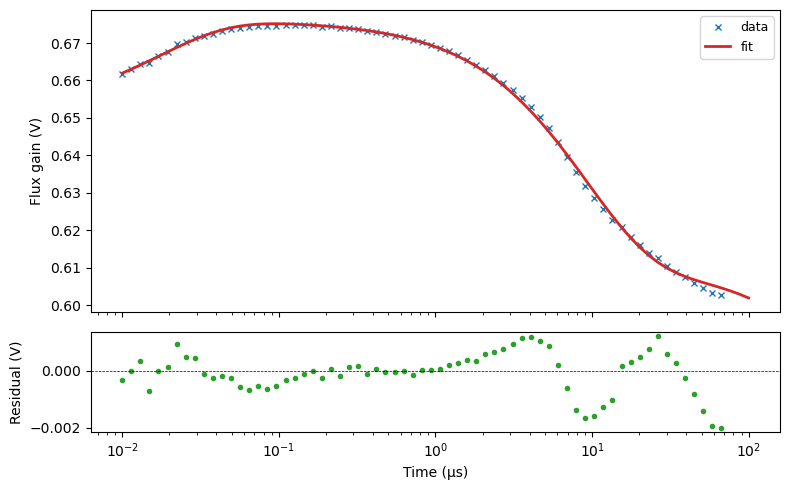

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

t = data["sweep_pts"]
# Convert frequencies directly to gain (voltage)
v_data = converter.freq_to_gain(expt.data["qubit_freq_list"])
v_fit = converter.freq_to_gain(data["step_fit_curve"])
show = ~data["outlier_mask"]

# (a) Step response in voltage
ax = axes[0]
ax.semilogx(t[show], v_data[show], 'x', ms=5, label='data')
ax.semilogx(t, v_fit, '-', color='C3', lw=2, label='fit')
# ax.axhline(p["gain_target"], color='gray', ls='--', lw=0.8,
#            label=f'target = {p["gain_target"]:.4f}')
ax.set_ylabel('Flux gain (V)')
ax.legend(fontsize=9)

# (b) Residuals
ax = axes[1]
resid = v_data - v_fit
ax.semilogx(t[show], resid[show], 'o', ms=3, color='C2')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('Residual (V)')
ax.set_xlabel('Time (µs)')

fig.tight_layout()
plt.show()

## Compare number of exponentials (n_exp = 2, 3, 4)


n_exp = 2: α₀ = 0.9125, RMS = 0.00159
  α1 = -0.1326, τ1 = 9.343 µs
  α2 = -1.8126, τ2 = 16740.398 µs

n_exp = 3: α₀ = 1.0953, RMS = 0.00122
  α1 = +0.0093, τ1 = 0.066 µs
  α2 = -0.1294, τ2 = 8.789 µs
  α3 = -2.0000, τ3 = 9331.937 µs

n_exp = 4: α₀ = nan, RMS = nan
  α1 = +nan, τ1 = nan µs
  α2 = +nan, τ2 = nan µs
  α3 = +nan, τ3 = nan µs
  α4 = +nan, τ4 = nan µs


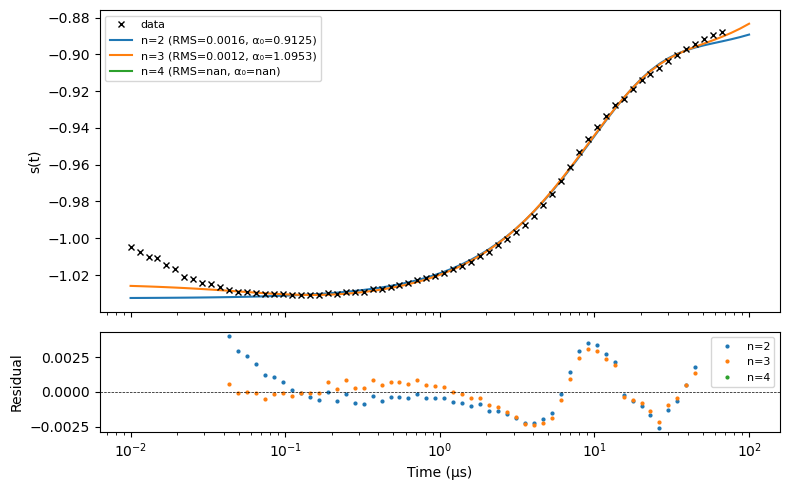

In [28]:
from slab_qick_calib.analysis.fitting import fit_step_response_flux

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

t = expt.data["sweep_pts"]
freq = expt.data["qubit_freq_list"]
show = ~data["outlier_mask"]

# Compute s_data once
gain_t = converter.freq_to_gain(freq)
gain_sweet = converter.sweet_spot
delta_gain = -0.35 - gain_sweet
s_data_all = (gain_t - gain_sweet) / delta_gain

axes[0].semilogx(t[show], s_data_all[show], 'kx', ms=4, label='data', zorder=10)

for n in [2, 3, 4]:
    params, s_d, s_f = fit_step_response_flux(
        t, freq, converter, -0.35,
        n_exp=n, t_range=(0.04, 50))

    # RMS residual in fit range
    mask = (t >= 0.04) & (t <= 50)
    rms = np.sqrt(np.mean((s_d[mask] - s_f[mask])**2))

    label = f'n={n} (RMS={rms:.4f}, α₀={params["alpha0"]:.4f})'
    axes[0].semilogx(t, s_f, '-', lw=1.5, label=label)
    axes[1].semilogx(t[mask & show], (s_d - s_f)[mask & show], 'o', ms=2, label=f'n={n}')

    print(f"\nn_exp = {n}: α₀ = {params['alpha0']:.4f}, RMS = {rms:.5f}")
    for i, (a, tau) in enumerate(zip(params['alphas'], params['taus'])):
        print(f"  α{i+1} = {a:+.4f}, τ{i+1} = {tau:.3f} µs")

axes[0].set_ylabel('s(t)')
axes[0].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (µs)')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Compute and validate IIR filter

In [29]:
from slab_qick_calib.analysis.flux_filter import compute_inverse_iir, validate_filter

# Use the best fit from above
p = data["step_params"]
print(f"Building IIR filter with α₀={p['alpha0']:.4f}")
for i, (a, tau) in enumerate(zip(p['alphas'], p['taus'])):
    print(f"  α{i+1} = {a:+.4f}, τ{i+1} = {tau:.3f} µs")

result = compute_inverse_iir(p["alphas"], p["taus"], fs=1000, alpha0=p["alpha0"])
val = validate_filter(p["alphas"], p["taus"], fs=1000, alpha0=p["alpha0"])

print(f"\nRound-trip max error: {val['max_error']:.2e}")

Building IIR filter with α₀=1.0969
  α1 = +0.0484, τ1 = 0.018 µs
  α2 = -0.1310, τ2 = 9.077 µs
  α3 = -1.9992, τ3 = 12534.640 µs

Round-trip max error: 5.20e-05


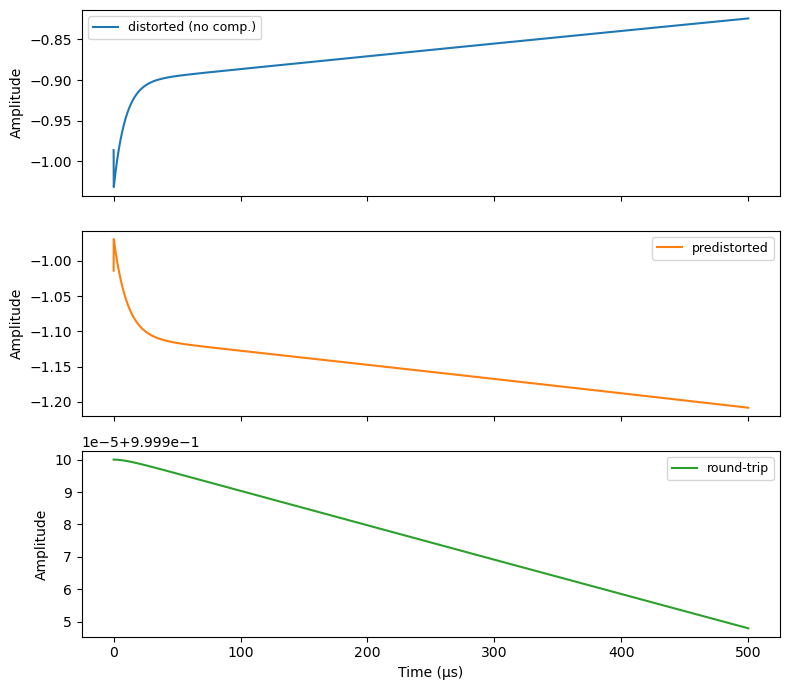

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

t_us = val["time"]
t_max_plot = max(p["taus"]) * 5
mask = t_us <= t_max_plot

# (a) Distorted step (no compensation)
axes[0].plot(t_us[mask], val["distorted"][mask], label="distorted (no comp.)")
#axes[0].plot(t_us[mask], val["step_input"][mask], 'k--', lw=0.8, label="ideal step")
axes[0].set_ylabel("Amplitude")
axes[0].legend(fontsize=9)

# (b) Predistorted waveform
axes[1].plot(t_us[mask], val["predistorted"][mask], color="C1", label="predistorted")
#axes[1].plot(t_us[mask], val["step_input"][mask], 'k--', lw=0.8)
axes[1].set_ylabel("Amplitude")
axes[1].legend(fontsize=9)

# (c) Round-trip (should be flat)
axes[2].plot(t_us[mask], val["round_trip"][mask], color="C2", label="round-trip")
#axes[2].plot(t_us[mask], val["step_input"][mask], 'k--', lw=0.8)
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (µs)")
axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()